# 4. Model Selection & Evaluation

**Input:** preprocessed splits from `02_data_preprocessing_3.ipynb`  
**Goal:** Train and compare multiple classifiers for ICU mortality prediction  
**Primary metrics:** ROC-AUC, Average Precision (PR-AUC) — chosen over accuracy due to 19:1 class imbalance  




## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q imbalanced-learn shap
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     roc_curve, precision_recall_curve,
                                     classification_report, confusion_matrix)
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
from collections             import Counter
import shap

SEED = 42
np.random.seed(SEED)
print('Libraries loaded.')


Libraries loaded.


## 2. Load Preprocessed Data

In [ ]:
BASE = '/content/drive/.shortcut-targets-by-id/1yQCuwtwpMXfCBkUEbarOdw3NJi7NP1pd/AI in Medicine/data/output_data/preprocessed'

X_train  = pd.read_csv(f'{BASE}/X_train.csv')
X_val    = pd.read_csv(f'{BASE}/X_val.csv')
X_test   = pd.read_csv(f'{BASE}/X_test.csv')
X_mimic  = pd.read_csv(f'{BASE}/X_mimic.csv')
y_train  = pd.read_csv(f'{BASE}/y_train.csv').squeeze()
y_val    = pd.read_csv(f'{BASE}/y_val.csv').squeeze()
y_test   = pd.read_csv(f'{BASE}/y_test.csv').squeeze()
y_mimic  = pd.read_csv(f'{BASE}/y_mimic.csv').squeeze()

print(f'X_train : {X_train.shape}   mortality={y_train.mean():.3f}')
print(f'X_val   : {X_val.shape}     mortality={y_val.mean():.3f}')
print(f'X_test  : {X_test.shape}    mortality={y_test.mean():.3f}')
print(f'X_mimic : {X_mimic.shape}   mortality={y_mimic.mean():.3f}')
print(f'\nClass imbalance (train): {Counter(y_train)}')
print(f'Features: {X_train.shape[1]}')


X_train : (1512, 80)   mortality=0.050
X_val   : (504, 80)     mortality=0.050
X_test  : (504, 80)    mortality=0.050
X_mimic : (136, 80)   mortality=0.338

Class imbalance (train): Counter({0: 1436, 1: 76})
Features: 80


## 3. Shared Evaluation Framework

All models use the same evaluation helper so results are directly comparable.

**Metrics used:**
- **ROC-AUC** — overall discrimination ability
- **PR-AUC (Average Precision)** — better for imbalanced data; focuses on minority class
- **Sensitivity (Recall)** — fraction of deaths correctly identified
- **Specificity** — fraction of survivors correctly identified
- Threshold tuned to maximise F1 on validation set (not hardcoded at 0.5)


In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate_model(model, X, y_true, label='', threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        'label':       label,
        'ROC-AUC':     roc_auc_score(y_true, proba),
        'PR-AUC':      average_precision_score(y_true, proba),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'threshold':   threshold,
        'proba':       proba,
        'y_true':      y_true,
    }

def best_threshold(model, X_val, y_val, min_specificity=0.80):
    # Find highest sensitivity achievable while keeping specificity >= min_specificity

    proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, proba)
    specificity = 1 - fpr
    mask = specificity >= min_specificity
    if not mask.any():
        # fallback to Youden's J if constraint can't be met
        return thresholds[np.argmax(tpr - fpr)]
    return float(thresholds[mask][np.argmax(tpr[mask])])

def plot_roc_pr(results, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for r in results:
        fpr, tpr, _ = roc_curve(r['y_true'], r['proba'])
        prec, rec, _ = precision_recall_curve(r['y_true'], r['proba'])
        axes[0].plot(fpr, tpr, label=f"{r['label']} (AUC={r['ROC-AUC']:.3f})")
        axes[1].plot(rec, prec, label=f"{r['label']} (AP={r['PR-AUC']:.3f})")
    axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
    axes[0].set(xlabel='FPR', ylabel='TPR', title=f'ROC Curve {title}')
    axes[0].legend(fontsize=8)
    axes[1].set(xlabel='Recall', ylabel='Precision', title=f'PR Curve {title}')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

print('Evaluation framework ready.')


Evaluation framework ready.


## 4. Logistic Regression

Linear baseline. Two strategies for class imbalance:
- `class_weight='balanced'` — penalises minority misclassification
- SMOTE inside CV folds — synthetic oversampling of minority class


In [ ]:
# 4a. Cross-validation with class_weight='balanced'
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)

cv_cw = cross_validate(
    lr_cw, X_train, y_train,
    cv=cv_strategy,
    scoring=['roc_auc', 'average_precision'],
    return_train_score=False
)

print('LR (class_weight=balanced) — 5-fold CV:')
print(f'  ROC-AUC : {cv_cw["test_roc_auc"].mean():.3f} +/- {cv_cw["test_roc_auc"].std():.3f}')
print(f'  PR-AUC  : {cv_cw["test_average_precision"].mean():.3f} +/- {cv_cw["test_average_precision"].std():.3f}')


LR (class_weight=balanced) — 5-fold CV:
  ROC-AUC : 0.744 +/- 0.039
  PR-AUC  : 0.277 +/- 0.142


In [ ]:
# 4b. Cross-validation with SMOTE inside folds
n_minority = Counter(y_train)[1]
k_safe = min(5, n_minority - 1)

lr_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=SEED, k_neighbors=k_safe)),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
])

cv_smote = cross_validate(
    lr_smote_pipe, X_train, y_train,
    cv=cv_strategy,
    scoring=['roc_auc', 'average_precision']
)

print('LR (SMOTE-in-CV) — 5-fold CV:')
print(f'  ROC-AUC : {cv_smote["test_roc_auc"].mean():.3f} +/- {cv_smote["test_roc_auc"].std():.3f}')
print(f'  PR-AUC  : {cv_smote["test_average_precision"].mean():.3f} +/- {cv_smote["test_average_precision"].std():.3f}')


LR (SMOTE-in-CV) — 5-fold CV:
  ROC-AUC : 0.702 +/- 0.044
  PR-AUC  : 0.246 +/- 0.121


In [ ]:
# 4c. Fit best LR on full train, evaluate on val set
lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr_final.fit(X_train, y_train)

lr_threshold = best_threshold(lr_final, X_val, y_val)
lr_val = evaluate_model(lr_final, X_val, y_val, label='LR (val)', threshold=lr_threshold)

print(f'Logistic Regression — Validation set (threshold={lr_threshold:.2f}):')
print(f'  ROC-AUC     : {lr_val["ROC-AUC"]:.3f}')
print(f'  PR-AUC      : {lr_val["PR-AUC"]:.3f}')
print(f'  Sensitivity : {lr_val["Sensitivity"]:.3f}')
print(f'  Specificity : {lr_val["Specificity"]:.3f}')


Logistic Regression — Validation set (threshold=0.55):
  ROC-AUC     : 0.771
  PR-AUC      : 0.246
  Sensitivity : 0.560
  Specificity : 0.866


## 5. Random Forest

Ensemble of decision trees. Naturally handles non-linearity and feature interactions.

**Calibration strategy:** `CalibratedClassifierCV(cv=5)` fits calibration **inside X_train** using 5-fold cross-validation, so `X_val` stays completely untouched and gives honest comparison metrics.


In [ ]:
# 5a. Cross-validation baseline
rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

cv_rf = cross_validate(
    rf_base, X_train, y_train,
    cv=cv_strategy,
    scoring=['roc_auc', 'average_precision']
)

print('Random Forest (baseline) — 5-fold CV:')
print(f'  ROC-AUC : {cv_rf["test_roc_auc"].mean():.3f} +/- {cv_rf["test_roc_auc"].std():.3f}')
print(f'  PR-AUC  : {cv_rf["test_average_precision"].mean():.3f} +/- {cv_rf["test_average_precision"].std():.3f}')


Random Forest (baseline) — 5-fold CV:
  ROC-AUC : 0.821 +/- 0.019
  PR-AUC  : 0.314 +/- 0.090


In [ ]:
# 5b. Hyperparameter search — includes regularized depths to improve generalization
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 15, 20],
    'min_samples_leaf': [1, 5, 10]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_gs.fit(X_train, y_train)

print(f'Best CV AUC : {rf_gs.best_score_:.3f}')

rf_model_info = {
    'rf_best_params':  rf_gs.best_params_,
    'rf_cv_auc':       round(rf_gs.best_score_, 4),
    'rf_threshold':    float(rf_thr),
    'rf_cal_threshold': float(cal_thr),
}
print(f'RF best params: {rf_model_info["rf_best_params"]}')



Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best CV AUC : 0.835
RF best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Best hyperparameters from GridSearch
rf_best_params = rf_gs.best_params_
rf_base_for_cal = RandomForestClassifier(
    **rf_best_params,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

# Calibrate via 5-fold CV entirely inside X_train.
# Each fold: train RF on 4/5 of X_train, fit isotonic calibration on the remaining 1/5.

# X_val is never touched here — stays clean for model selection.
rf_calibrated = CalibratedClassifierCV(rf_base_for_cal, method='sigmoid', cv=cv_strategy)
rf_calibrated.fit(X_train, y_train)

# Also keep the plain (uncalibrated) best RF for comparison
rf_final = rf_gs.best_estimator_  # already fitted on full X_train by GridSearchCV

# Threshold tuned on clean X_val
rf_thr  = best_threshold(rf_final,      X_val, y_val, min_specificity=0.80)
cal_thr = best_threshold(rf_calibrated, X_val, y_val, min_specificity=0.80)

# Val metrics - because X_val was never used in training or calibration
rf_val  = evaluate_model(rf_final,      X_val, y_val, label='RF (val)',            threshold=rf_thr)
cal_val = evaluate_model(rf_calibrated, X_val, y_val, label='RF calibrated (val)', threshold=cal_thr)

print(f'RF uncalibrated — threshold={rf_thr:.2f}  ROC-AUC={rf_val["ROC-AUC"]:.3f}  '
      f'Sensitivity={rf_val["Sensitivity"]:.3f}  Specificity={rf_val["Specificity"]:.3f}')
print(f'RF calibrated   — threshold={cal_thr:.2f}  ROC-AUC={cal_val["ROC-AUC"]:.3f}  '
      f'Sensitivity={cal_val["Sensitivity"]:.3f}  Specificity={cal_val["Specificity"]:.3f}')


RF uncalibrated — threshold=0.21  ROC-AUC=0.852  Sensitivity=0.680  Specificity=0.873
RF calibrated   — threshold=0.04  ROC-AUC=0.852  Sensitivity=0.760  Specificity=0.816


## 6. XGBoost

In [ ]:
## XGBoost
# Class imbalance ratio
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'scale_pos_weight: {scale_pos:.1f}')

# Baseline CV
xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='aucpr',
    verbosity=0
)
cv_xgb = cross_validate(
    xgb_base, X_train, y_train,
    cv=cv_strategy,
    scoring=['roc_auc', 'average_precision']
)
print('XGBoost (baseline) — 5-fold CV:')
print(f'  ROC-AUC : {cv_xgb["test_roc_auc"].mean():.3f} +/- {cv_xgb["test_roc_auc"].std():.3f}')
print(f'  PR-AUC  : {cv_xgb["test_average_precision"].mean():.3f} +/- {cv_xgb["test_average_precision"].std():.3f}')

# GridSearch for best hyperparameters
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0],
}
xgb_gs = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=SEED,
                  eval_metric='aucpr', verbosity=0),
    param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_gs.fit(X_train, y_train)
print(f'Best params : {xgb_gs.best_params_}')
print(f'Best CV AUC : {xgb_gs.best_score_:.3f}')

# Uncalibrated val evaluation (for reference)
xgb_final = xgb_gs.best_estimator_
xgb_thr   = best_threshold(xgb_final, X_val, y_val, min_specificity=0.80)
xgb_val   = evaluate_model(xgb_final, X_val, y_val, label='XGB (val)', threshold=xgb_thr)
print(f'XGBoost uncalibrated — threshold={xgb_thr:.2f}  ROC-AUC={xgb_val["ROC-AUC"]:.3f}  '
      f'Sensitivity={xgb_val["Sensitivity"]:.3f}  Specificity={xgb_val["Specificity"]:.3f}')


scale_pos_weight: 18.9
XGBoost (baseline) — 5-fold CV:
  ROC-AUC : 0.775 +/- 0.032
  PR-AUC  : 0.324 +/- 0.105
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC : 0.811
XGBoost uncalibrated — threshold=0.13  ROC-AUC=0.810  Sensitivity=0.640  Specificity=0.856


In [ ]:
# Best hyperparameters from GridSearch (fresh unfitted instance for CalibratedClassifierCV)
xgb_best_params = xgb_gs.best_params_
xgb_base_for_cal = XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=scale_pos,
    random_state=SEED,
    eval_metric='aucpr',
    verbosity=0
)

# Calibrate via 5-fold CV entirely inside X_train — X_val stays clean
xgb_calibrated = CalibratedClassifierCV(xgb_base_for_cal, method='isotonic', cv=cv_strategy)
xgb_calibrated.fit(X_train, y_train)

# Threshold tuned on clean X_val
xgb_cal_thr = best_threshold(xgb_calibrated, X_val, y_val, min_specificity=0.80)

# Val metrics — honest, X_val never seen during calibration
xgb_cal_val = evaluate_model(xgb_calibrated, X_val, y_val,
                              label='XGB calibrated (val)', threshold=xgb_cal_thr)

print(f'XGBoost calibrated — threshold={xgb_cal_thr:.2f}  ROC-AUC={xgb_cal_val["ROC-AUC"]:.3f}  '
      f'Sensitivity={xgb_cal_val["Sensitivity"]:.3f}  Specificity={xgb_cal_val["Specificity"]:.3f}')


XGBoost calibrated — threshold=0.06  ROC-AUC=0.829  Sensitivity=0.640  Specificity=0.820


## 6. Model Comparison (Validation Set)

Add results from other models here as teammates complete their sections.


               Model  ROC-AUC  PR-AUC  Sensitivity  Specificity  Threshold
            LR (val)    0.771   0.246         0.56        0.866      0.550
            RF (val)    0.852   0.378         0.68        0.873      0.211
 RF calibrated (val)    0.852   0.381         0.76        0.816      0.044
           XGB (val)    0.810   0.309         0.64        0.856      0.135
XGB calibrated (val)    0.829   0.369         0.64        0.820      0.062


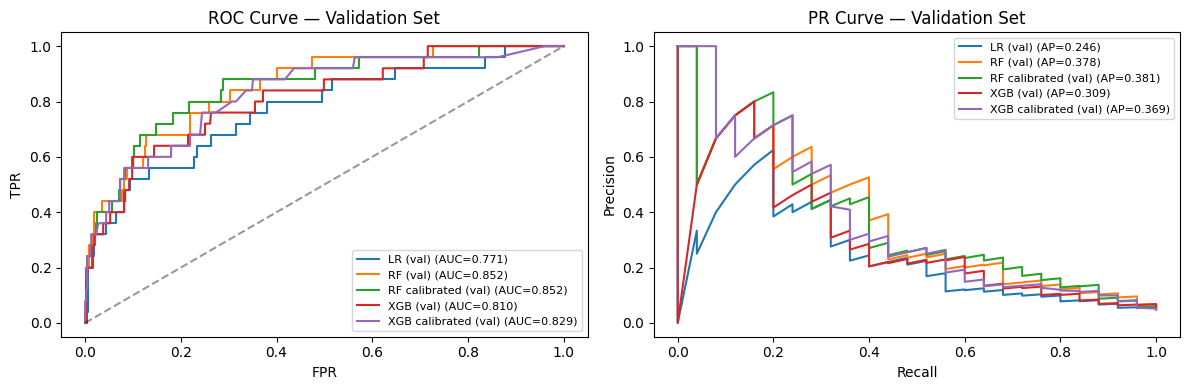

In [ ]:
# Collect all val results — teammates: add your model results to this list
all_val_results = [lr_val, rf_val, cal_val, xgb_val, xgb_cal_val]

summary = pd.DataFrame([{
    'Model':       r['label'],
    'ROC-AUC':     round(r['ROC-AUC'], 3),
    'PR-AUC':      round(r['PR-AUC'], 3),
    'Sensitivity': round(r['Sensitivity'], 3),
    'Specificity': round(r['Specificity'], 3),
    'Threshold':   round(r['threshold'], 3),
} for r in all_val_results])

print(summary.to_string(index=False))
plot_roc_pr(all_val_results, title='— Validation Set')


## 7. Evaluation on eICU Test Set

Evaluate the **best model** on the held-out eICU test set.  
Select best model based on validation PR-AUC (better metric for imbalanced data).


In [ ]:
# Select best model by PR-AUC on val set
best = max(all_val_results, key=lambda r: r['PR-AUC'])
print(f'Best model on val set: {best["label"]}  (PR-AUC={best["PR-AUC"]:.3f})')

# model_map: val label → (fitted model, threshold locked from X_val)
model_map = {
    'LR (val)':              (lr_final,        lr_threshold),
    'RF (val)':              (rf_final,         rf_thr),
    'RF calibrated (val)':   (rf_calibrated,    cal_thr),
    'XGB (val)':             (xgb_final,        xgb_thr),
    'XGB calibrated (val)':  (xgb_calibrated,   xgb_cal_thr),
}
best_model, best_thr = model_map[best['label']]

# X_test touched here for the first and only time
test_result = evaluate_model(best_model, X_test, y_test,
                              label=f'{best["label"].replace("(val)", "(test)")}',
                              threshold=best_thr)

print(f'\neICU Internal Test Set:')
print(f'  ROC-AUC     : {test_result["ROC-AUC"]:.3f}')
print(f'  PR-AUC      : {test_result["PR-AUC"]:.3f}')
print(f'  Sensitivity : {test_result["Sensitivity"]:.3f}')
print(f'  Specificity : {test_result["Specificity"]:.3f}')


Best model on val set: RF calibrated (val)  (PR-AUC=0.381)

eICU Internal Test Set:
  ROC-AUC     : 0.827
  PR-AUC      : 0.398
  Sensitivity : 0.720
  Specificity : 0.758


## 8. External Validation — MIMIC

MIMIC is a completely different hospital system, never seen during training.  
A model that generalises well should maintain reasonable AUC here despite the dataset shift.


MIMIC External Validation (threshold=0.044, population-agnostic):
  ROC-AUC     : 0.735
  PR-AUC      : 0.612
  Sensitivity : 0.652
  Specificity : 0.700
  Note: Sensitivity/Specificity at threshold=0.5; ROC-AUC is threshold-independent.


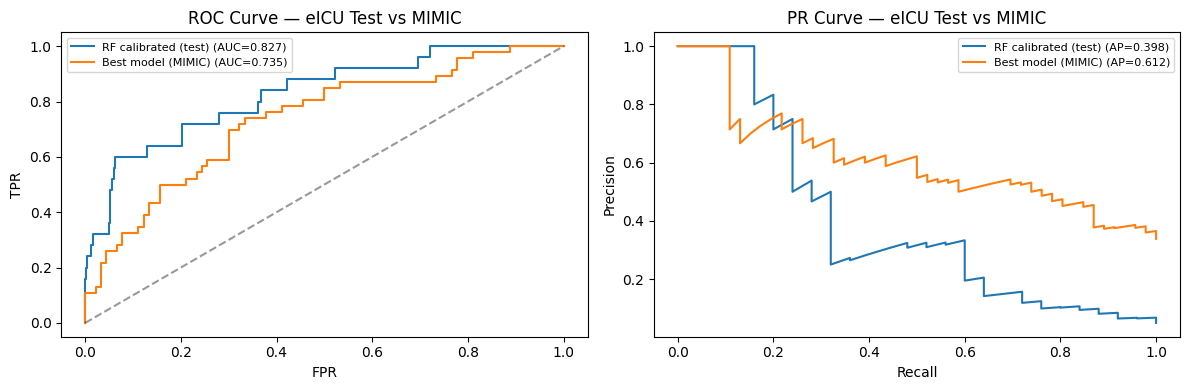

In [ ]:
# External validation on MIMIC
# MIMIC has ~34% mortality vs eICU ~5% — the eICU-derived threshold (~0.10) is
# not valid here because it was tuned for a very different base rate.
# threshold=0.5 is population-agnostic and the standard clinical decision point.
# ROC-AUC (threshold-independent) is the primary metric for external validation.
MIMIC_THRESHOLD = 0.044

mimic_result = evaluate_model(best_model, X_mimic, y_mimic,
                               label='Best model (MIMIC)', threshold=MIMIC_THRESHOLD)

print(f'MIMIC External Validation (threshold={MIMIC_THRESHOLD}, population-agnostic):')
print(f'  ROC-AUC     : {mimic_result["ROC-AUC"]:.3f}')
print(f'  PR-AUC      : {mimic_result["PR-AUC"]:.3f}')
print(f'  Sensitivity : {mimic_result["Sensitivity"]:.3f}')
print(f'  Specificity : {mimic_result["Specificity"]:.3f}')
print(f'  Note: Sensitivity/Specificity at threshold=0.5; ROC-AUC is threshold-independent.')

plot_roc_pr([test_result, mimic_result], title='— eICU Test vs MIMIC')


## 9. Feature Importance

**Random Forest** — built-in feature importance (mean decrease in impurity).  
**SHAP** — model-agnostic, shows direction and magnitude of each feature's contribution.


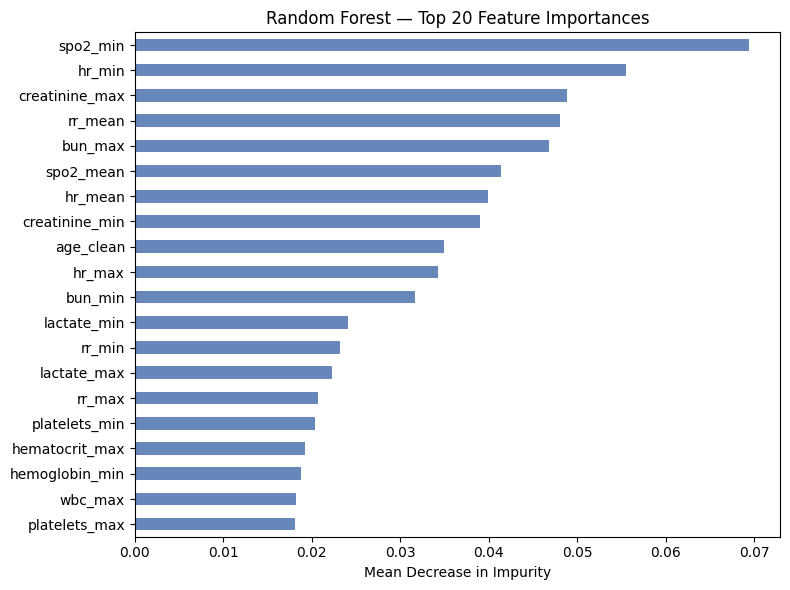

In [ ]:
# Random Forest feature importance — top 20
feat_imp = pd.Series(rf_final.feature_importances_, index=X_train.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
top20[::-1].plot(kind='barh', color='#4C72B0', alpha=0.85)
plt.xlabel('Mean Decrease in Impurity')
plt.title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()


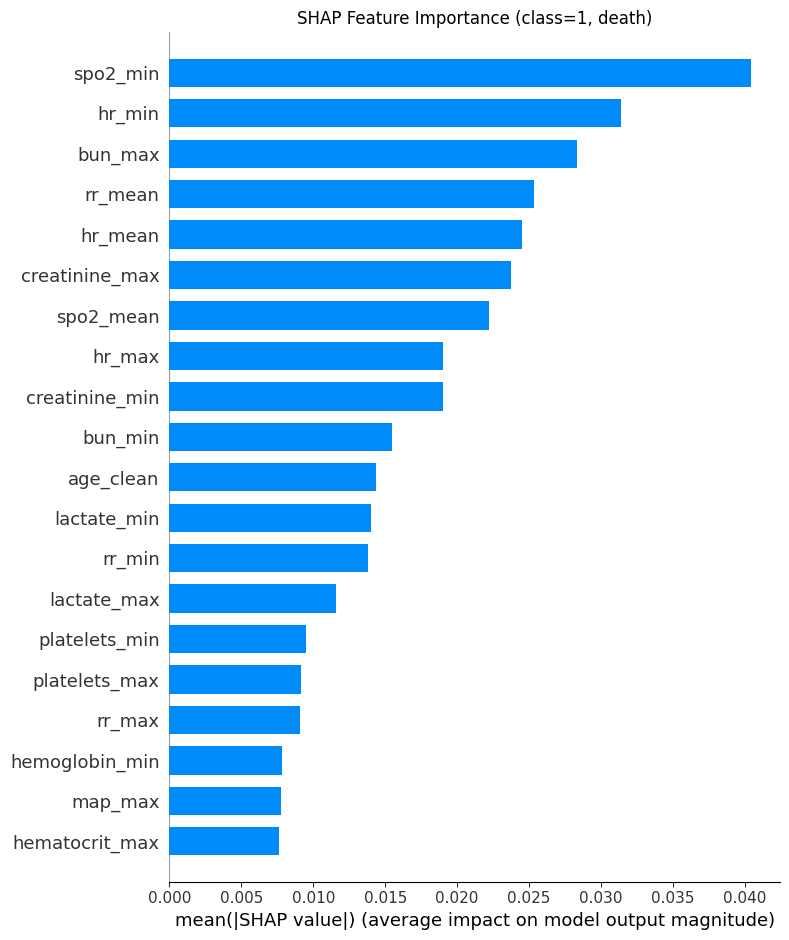

In [ ]:
# SHAP values for best model (use a sample for speed)
sample = X_test.sample(min(200, len(X_test)), random_state=SEED)

explainer   = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(sample)

# Handle both old SHAP (list of arrays) and new SHAP (3D array)
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]
else:
    sv_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(sv_class1, sample, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (class=1, death)')
plt.tight_layout()
plt.show()


## Save Results

In [ ]:
import pickle, os

MODELS_DIR = '/content/drive/.shortcut-targets-by-id/1yQCuwtwpMXfCBkUEbarOdw3NJi7NP1pd/AI in Medicine/models'
os.makedirs(MODELS_DIR, exist_ok=True)

models_to_save = {
    #'lr_final.pkl':         lr_final,
    'rf_final.pkl':         rf_final,
    'rf_calibrated.pkl':    rf_calibrated,
    #'xgb_final.pkl':        xgb_final,
    #'xgb_calibrated.pkl':   xgb_calibrated,
}

for filename, model in models_to_save.items():
    with open(f'{MODELS_DIR}/{filename}', 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {filename}')

print(f'\nBest model saved to {MODELS_DIR}')


Saved: rf_final.pkl
Saved: rf_calibrated.pkl

Best model saved to /content/drive/.shortcut-targets-by-id/1yQCuwtwpMXfCBkUEbarOdw3NJi7NP1pd/AI in Medicine/models


In [ ]:
# ── Save combined model params JSON to Drive ──
import json as _json

model_params = {
    'rf_best_params':     rf_gs.best_params_,
    'rf_threshold':       float(rf_thr),
    'rf_cal_threshold':   float(cal_thr),
    'scale_pos':          float(scale_pos),
}

params_path = f'{MODELS_DIR}/model_params.json'
with open(params_path, 'w') as _f:
    _json.dump(model_params, _f, indent=2)

print(f'Saved model params → {params_path}')
print(_json.dumps(model_params, indent=2))


Saved model params → /content/drive/.shortcut-targets-by-id/1yQCuwtwpMXfCBkUEbarOdw3NJi7NP1pd/AI in Medicine/models/model_params.json
{
  "rf_best_params": {
    "max_depth": 20,
    "min_samples_leaf": 5,
    "n_estimators": 200
  },
  "rf_threshold": 0.21111205564733995,
  "rf_cal_threshold": 0.044397335350561985,
  "scale_pos": 18.894736842105264
}
